<a href="https://www.kaggle.com/code/lalit7881/screen-time-vs-mental-health-ml-ready-eda-100?scriptVersionId=338755771" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kylefengkfeng209/screen-time-vs-mental-health-ml-ready/bdi_and_screen_items.csv
/kaggle/input/datasets/kylefengkfeng209/screen-time-vs-mental-health-ml-ready/screen_time_mental_health.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/kylefengkfeng209/screen-time-vs-mental-health-ml-ready/screen_time_mental_health.csv")

In [3]:
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [4]:
df.tail()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
4805,4806,Girl,2.333,2.07,1.50,8.76,4.08,2.00,20,1
4806,4807,Boy,4.333,6.07,1.00,6.60,7.46,3.46,6,0
4807,4808,Girl,2.333,2.07,1.25,6.61,5.25,1.62,1,0
4808,4809,Girl,3.667,4.64,1.25,7.15,5.54,2.83,0,0
4809,4810,Boy,3.667,2.93,1.50,8.75,8.00,4.12,5,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   object 
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 375.9+ KB


In [6]:
df.describe()

,subject_id,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
count,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000
mean,2405.500000,3.219097,3.958299,1.901611,7.689067,5.570553,2.400200,7.271518,0.163617
std,1388.671727,1.026348,2.387289,0.851176,1.270213,1.415505,1.137931,7.703156,0.369967
min,1.000000,1.000000,0.500000,1.000000,1.360000,1.670000,-3.030000,0.000000,0.000000
25%,1203.250000,2.333000,2.070000,1.250000,7.050000,4.540000,1.580000,2.000000,0.000000
50%,2405.500000,3.000000,3.500000,1.750000,7.870000,5.420000,2.290000,5.000000,0.000000
75%,3607.750000,4.000000,5.500000,2.250000,8.540000,6.500000,3.120000,10.000000,0.000000
max,4810.000000,6.000000,10.000000,6.000000,12.210000,10.500000,6.960000,51.000000,1.000000


In [7]:
df.isnull().sum()

subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

subject_id                    int64
sex                          object
screen_time_index           float64
est_leisure_screen_hours    float64
sleep_quality_index         float64
avg_sleep_hours             float64
midsleep_weekend_hours      float64
social_jetlag_hours         float64
bdi_total                     int64
depressed                     int64
dtype: object

In [10]:
df.shape

(4810, 10)

In [11]:
df.columns


Index(['subject_id', 'sex', 'screen_time_index', 'est_leisure_screen_hours',
       'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours',
       'social_jetlag_hours', 'bdi_total', 'depressed'],
      dtype='object')

In [12]:
df.nunique()

subject_id                  4810
sex                            2
screen_time_index             16
est_leisure_screen_hours      32
sleep_quality_index           21
avg_sleep_hours              608
midsleep_weekend_hours       400
social_jetlag_hours          382
bdi_total                     51
depressed                      2
dtype: int64

## EDA

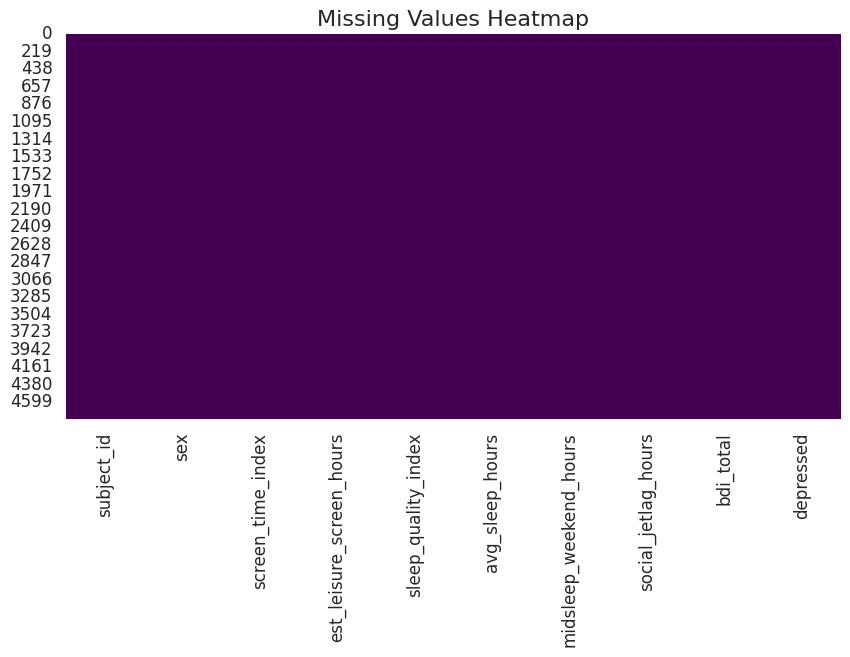

subject_id                    int64
sex                          object
screen_time_index           float64
est_leisure_screen_hours    float64
sleep_quality_index         float64
avg_sleep_hours             float64
midsleep_weekend_hours      float64
social_jetlag_hours         float64
bdi_total                     int64
depressed                     int64
dtype: object


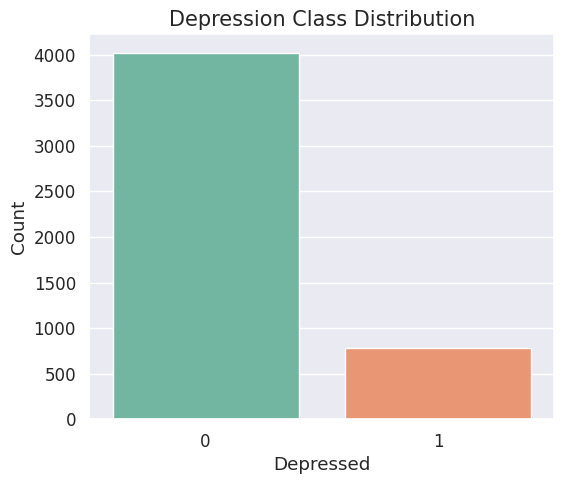

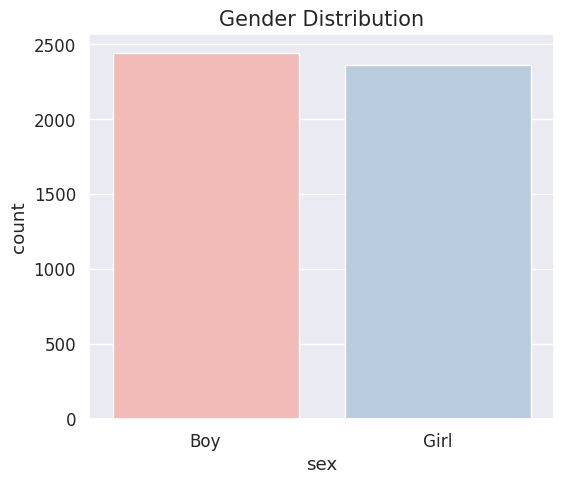

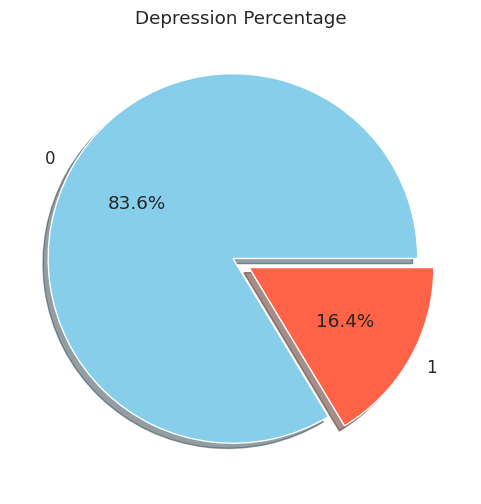

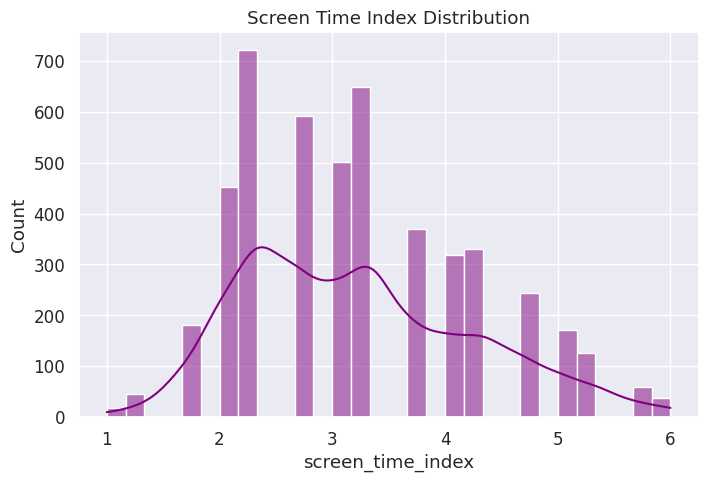

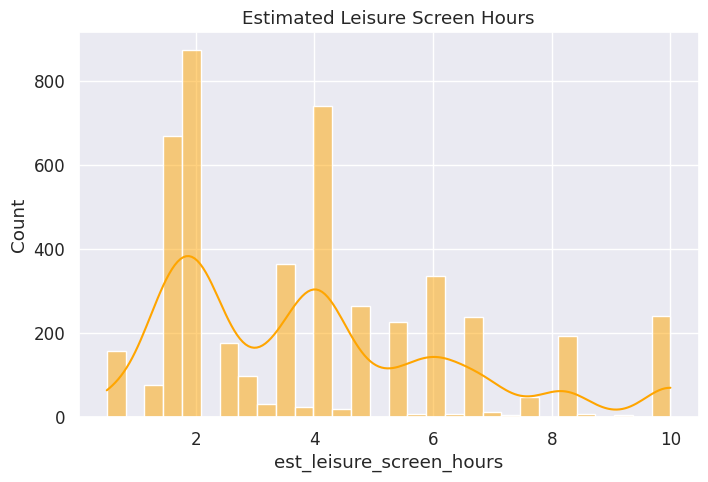

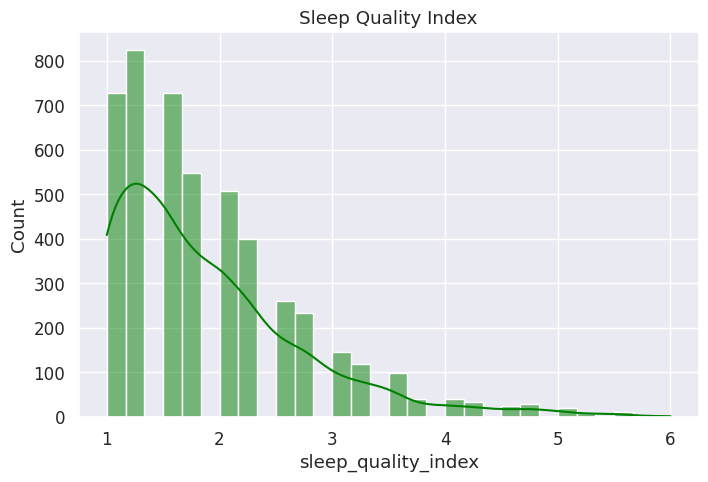

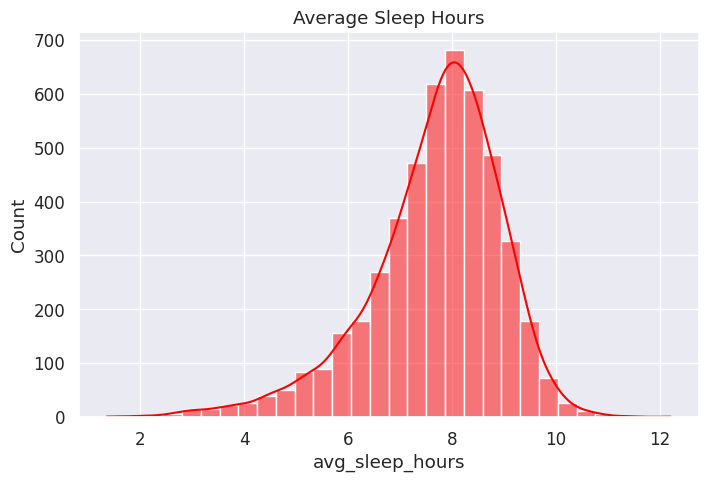

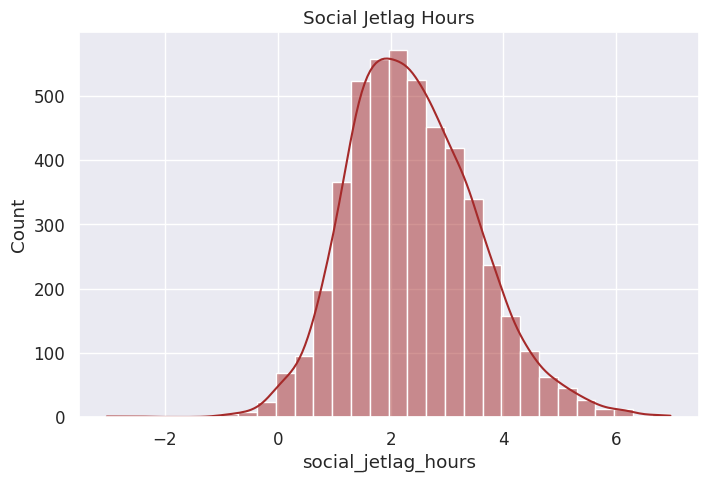

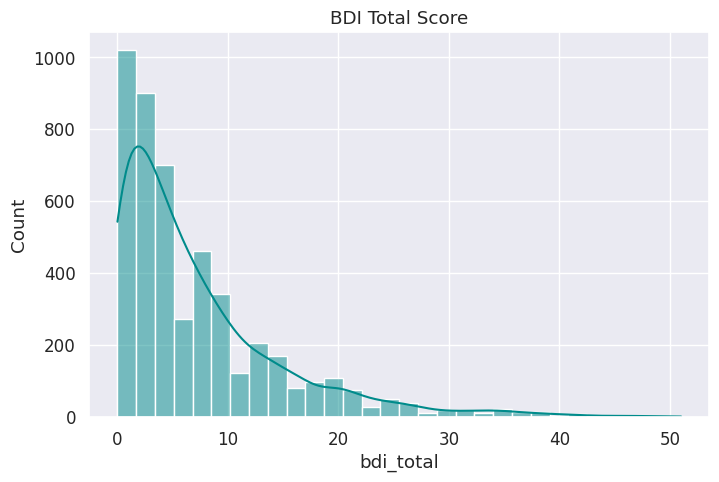

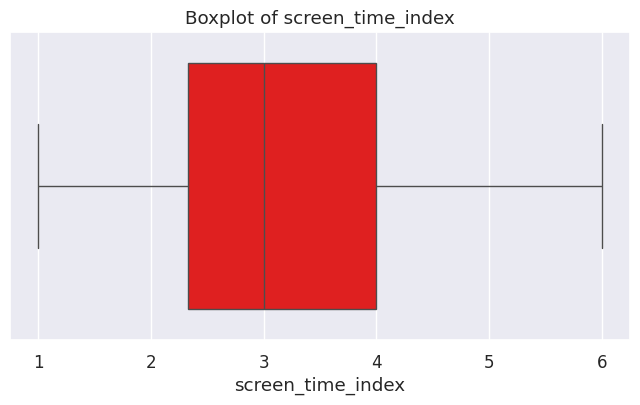

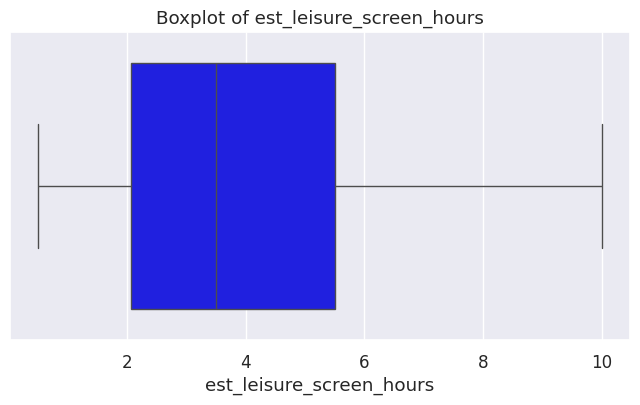

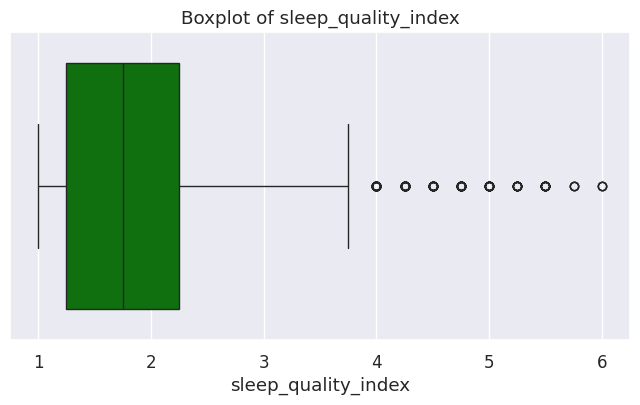

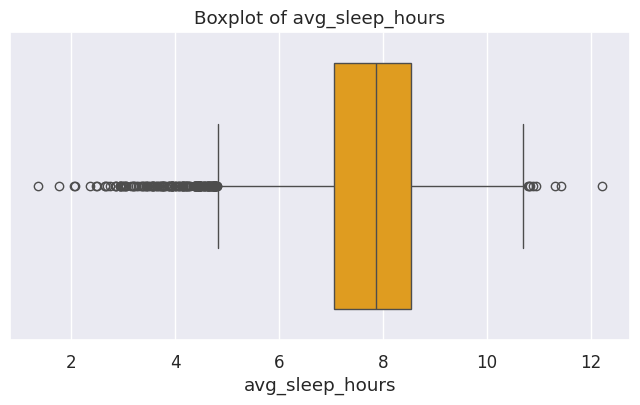

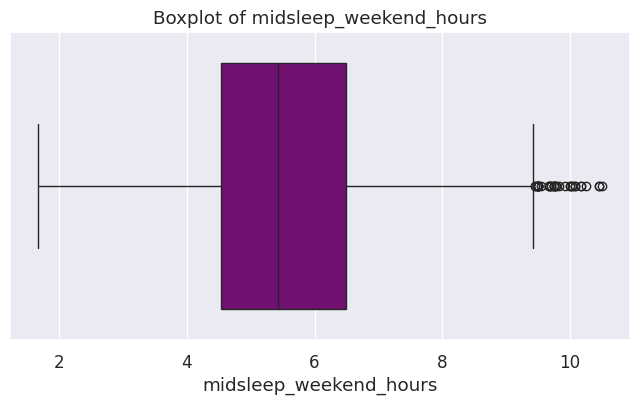

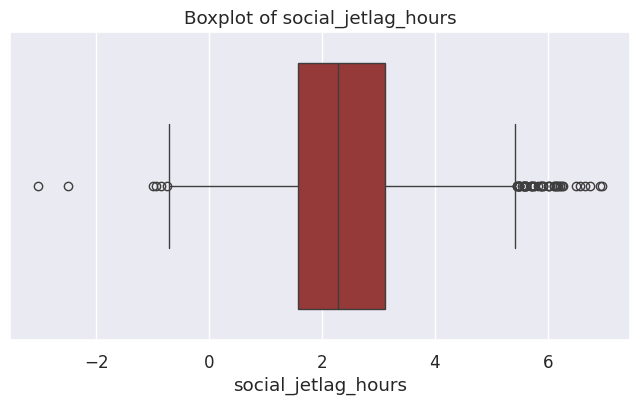

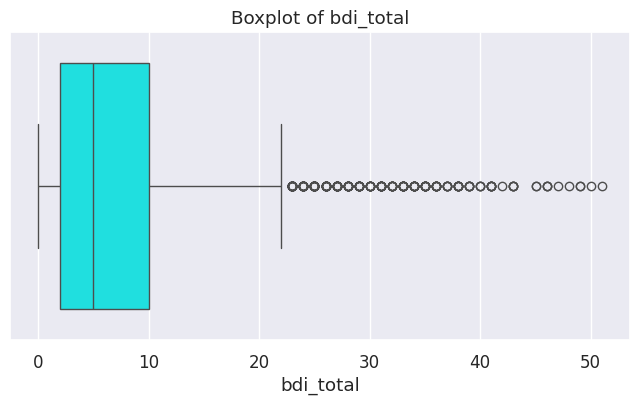

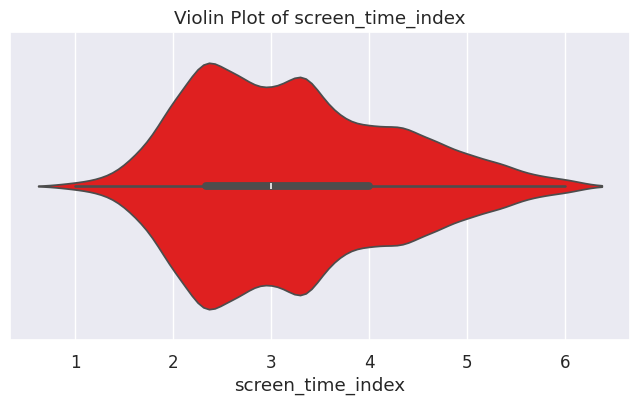

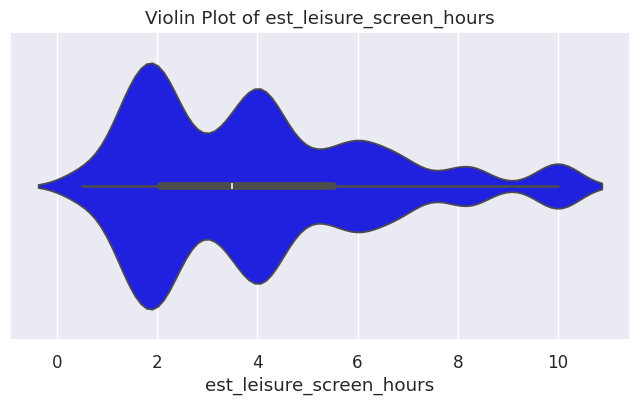

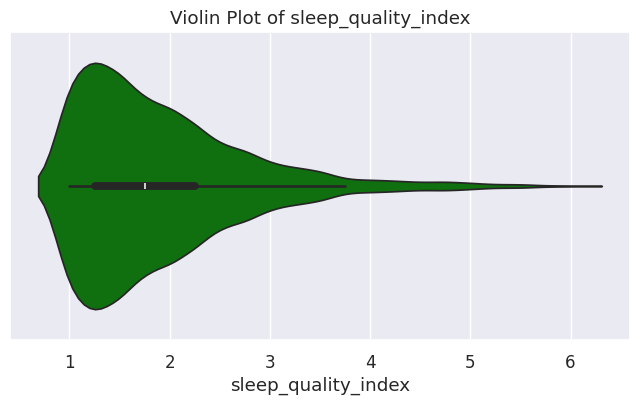

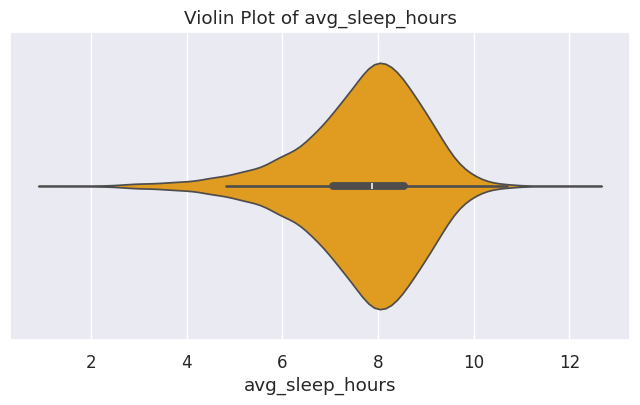

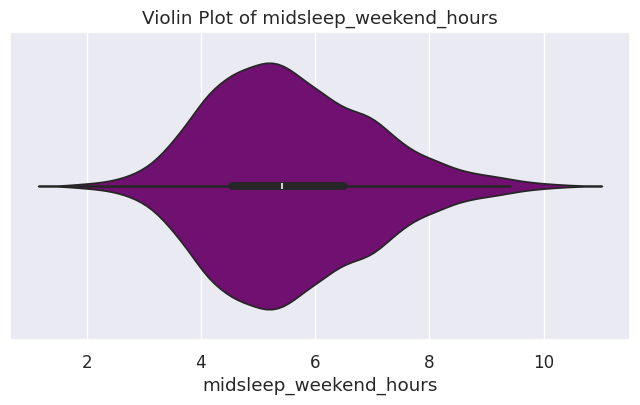

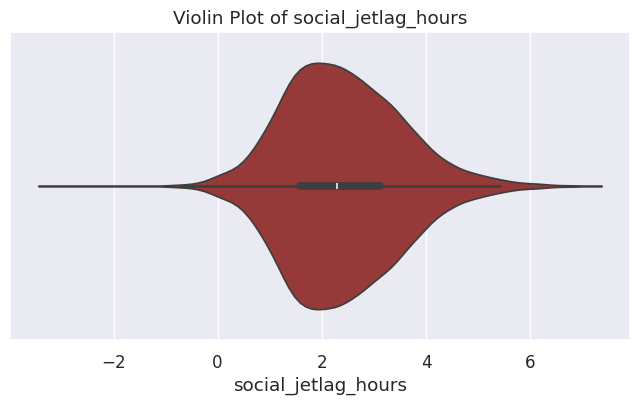

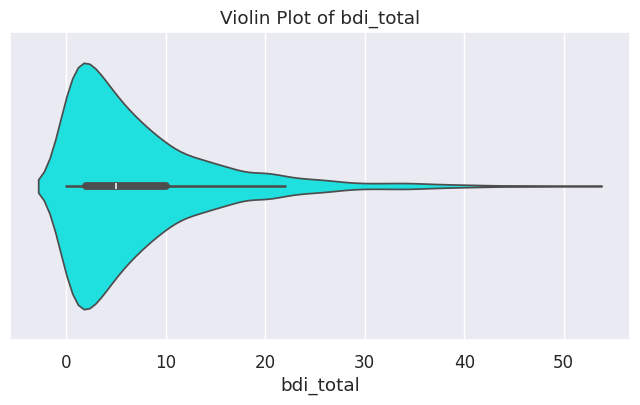

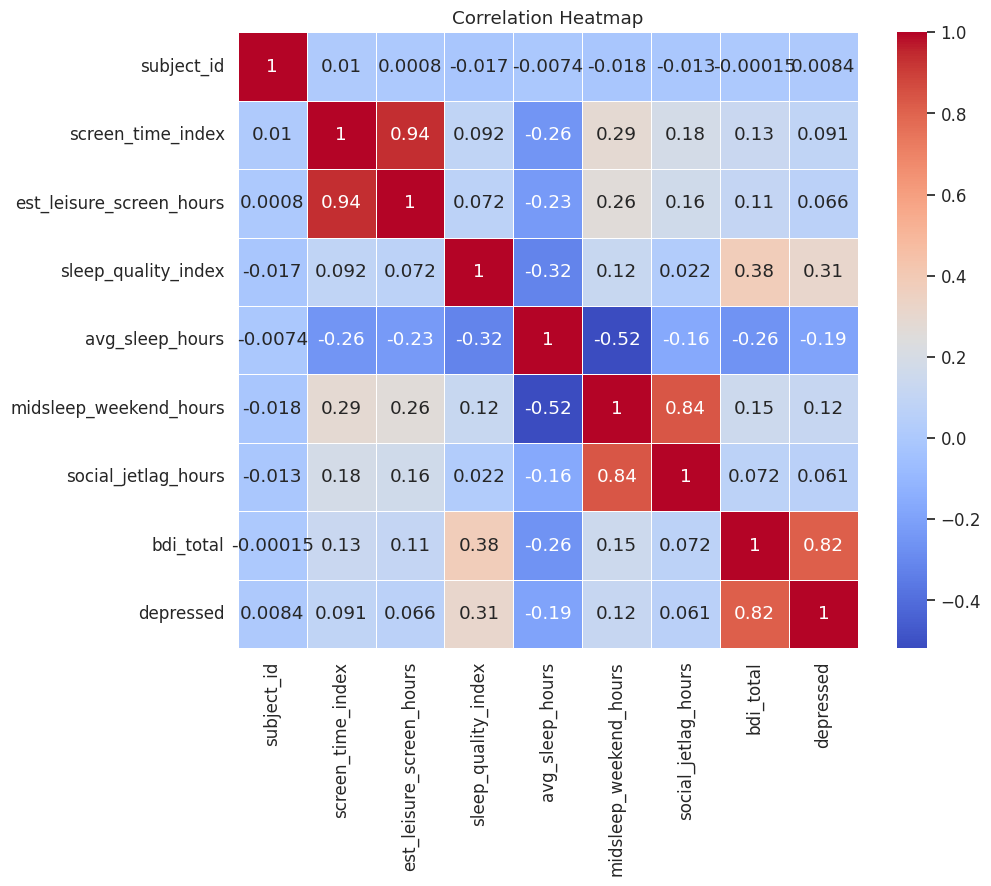

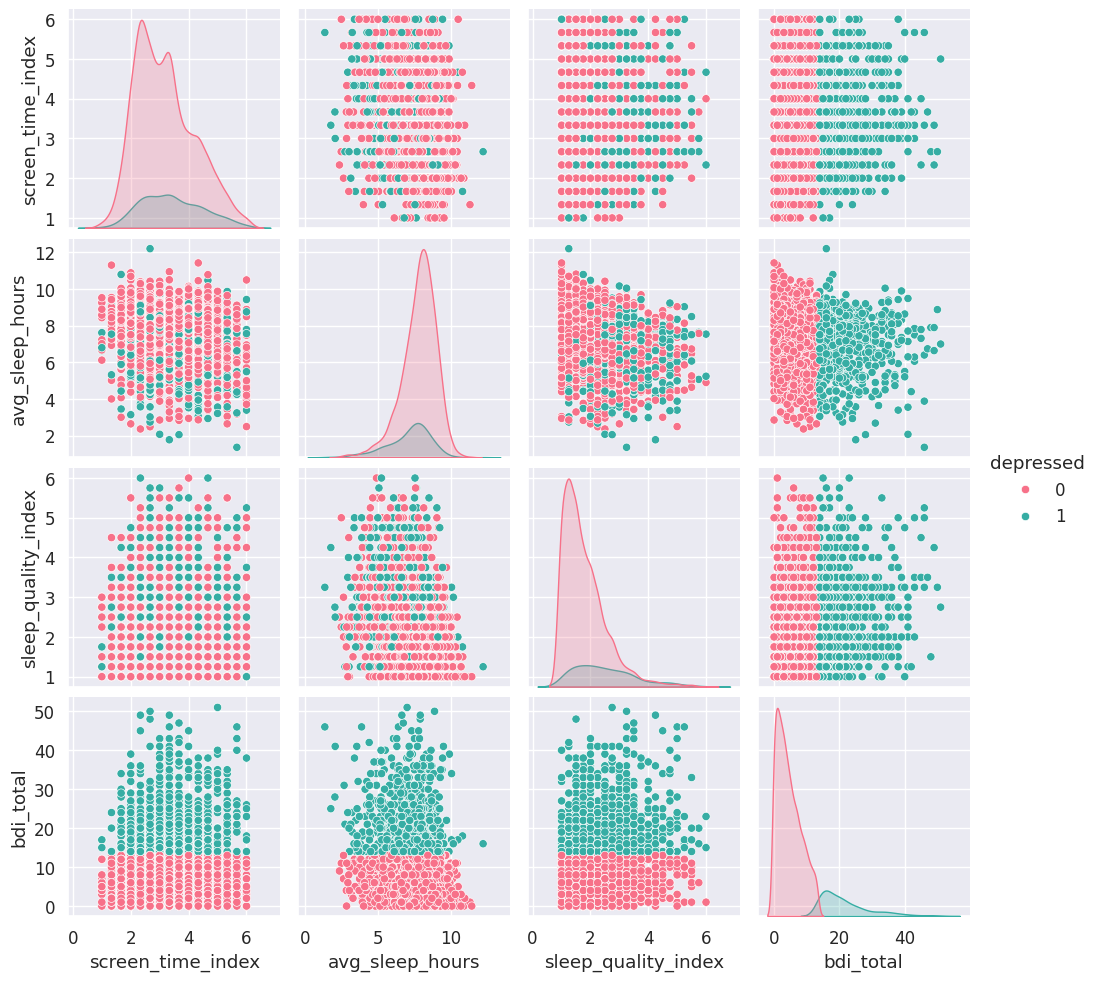

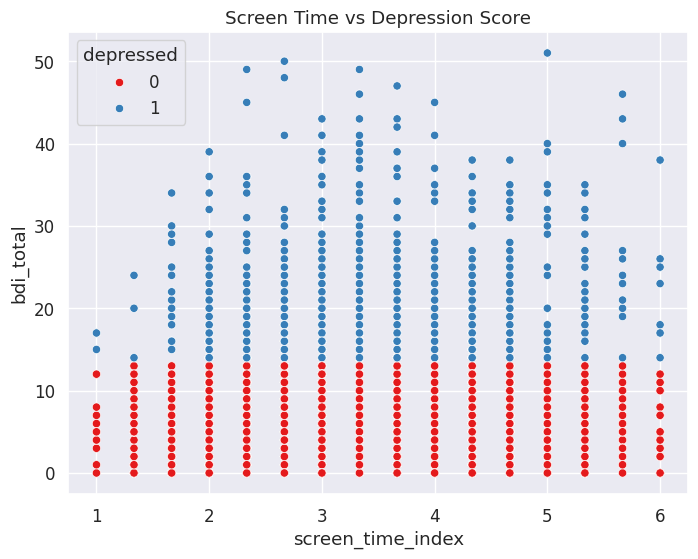

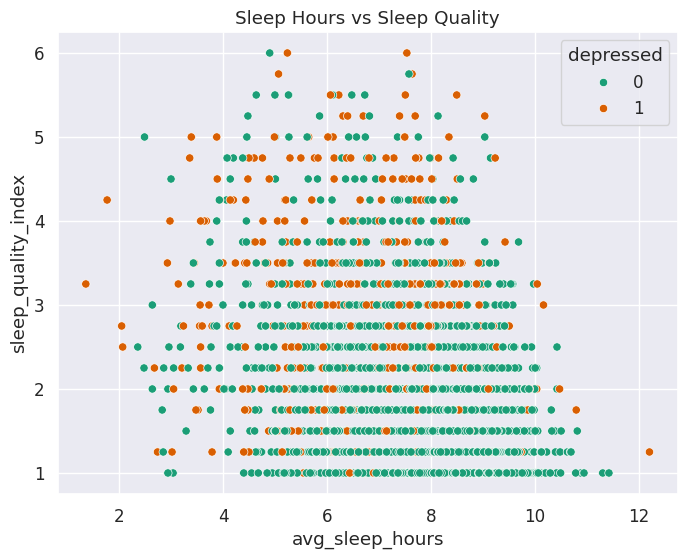

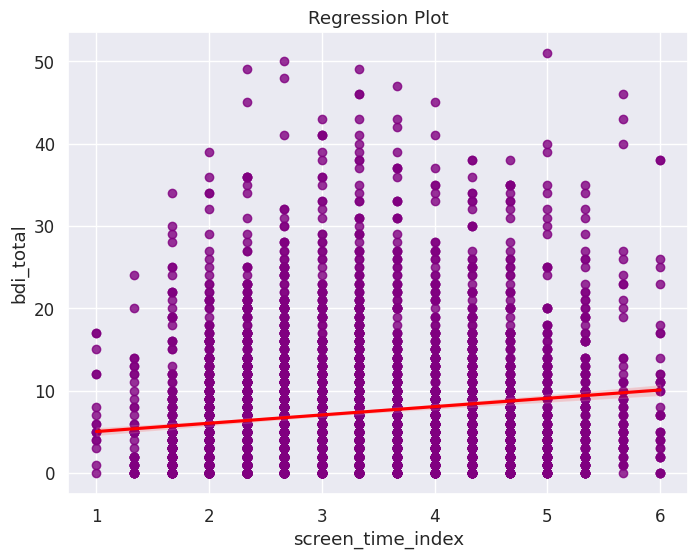

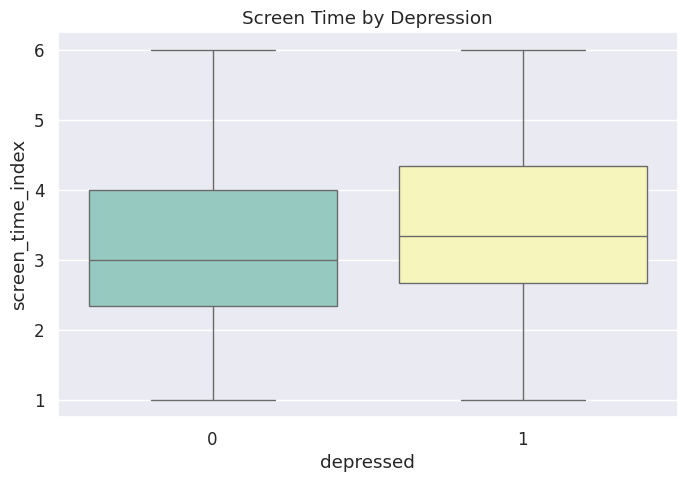

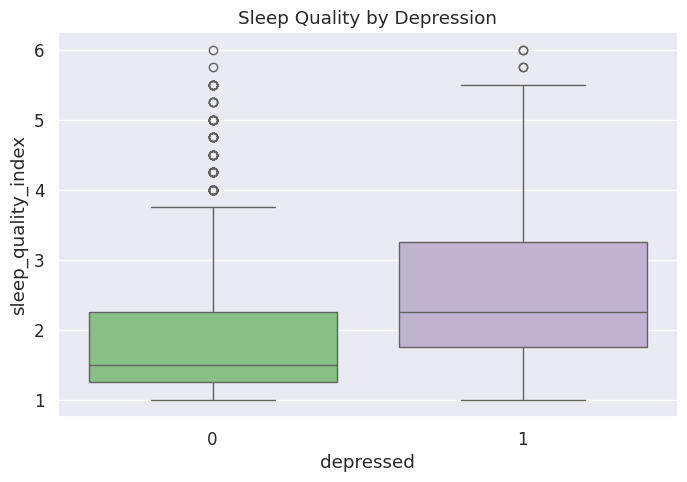

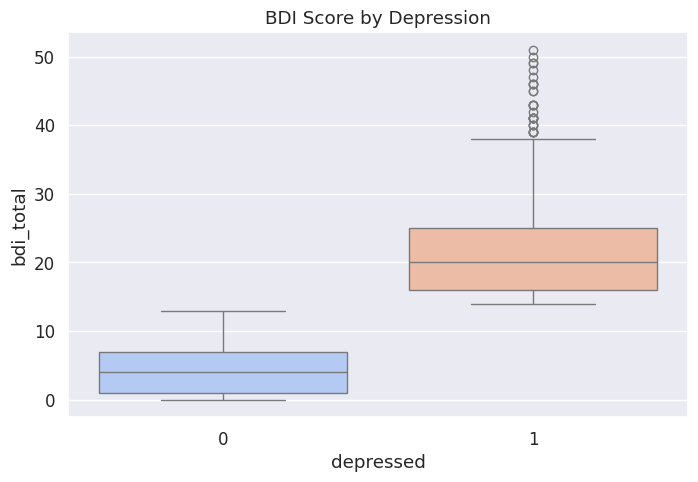

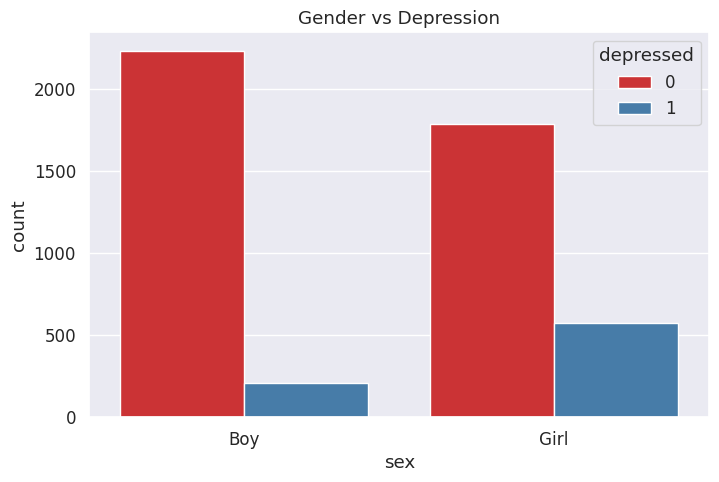

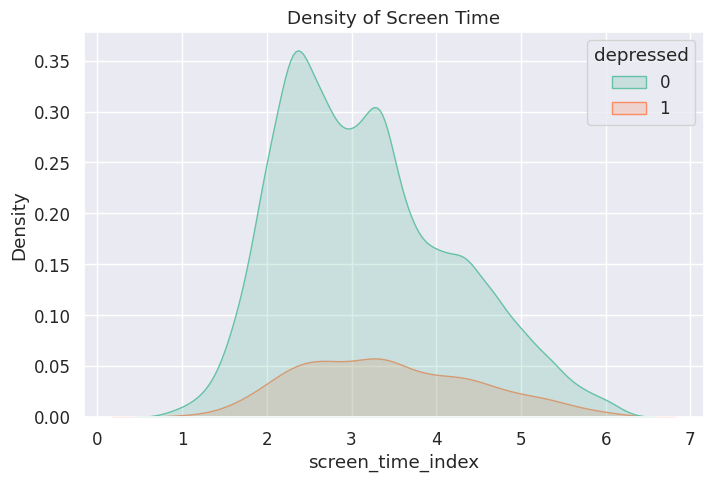

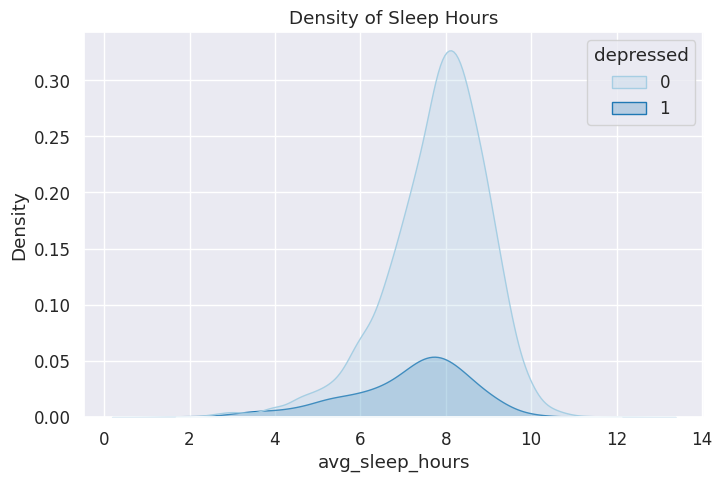

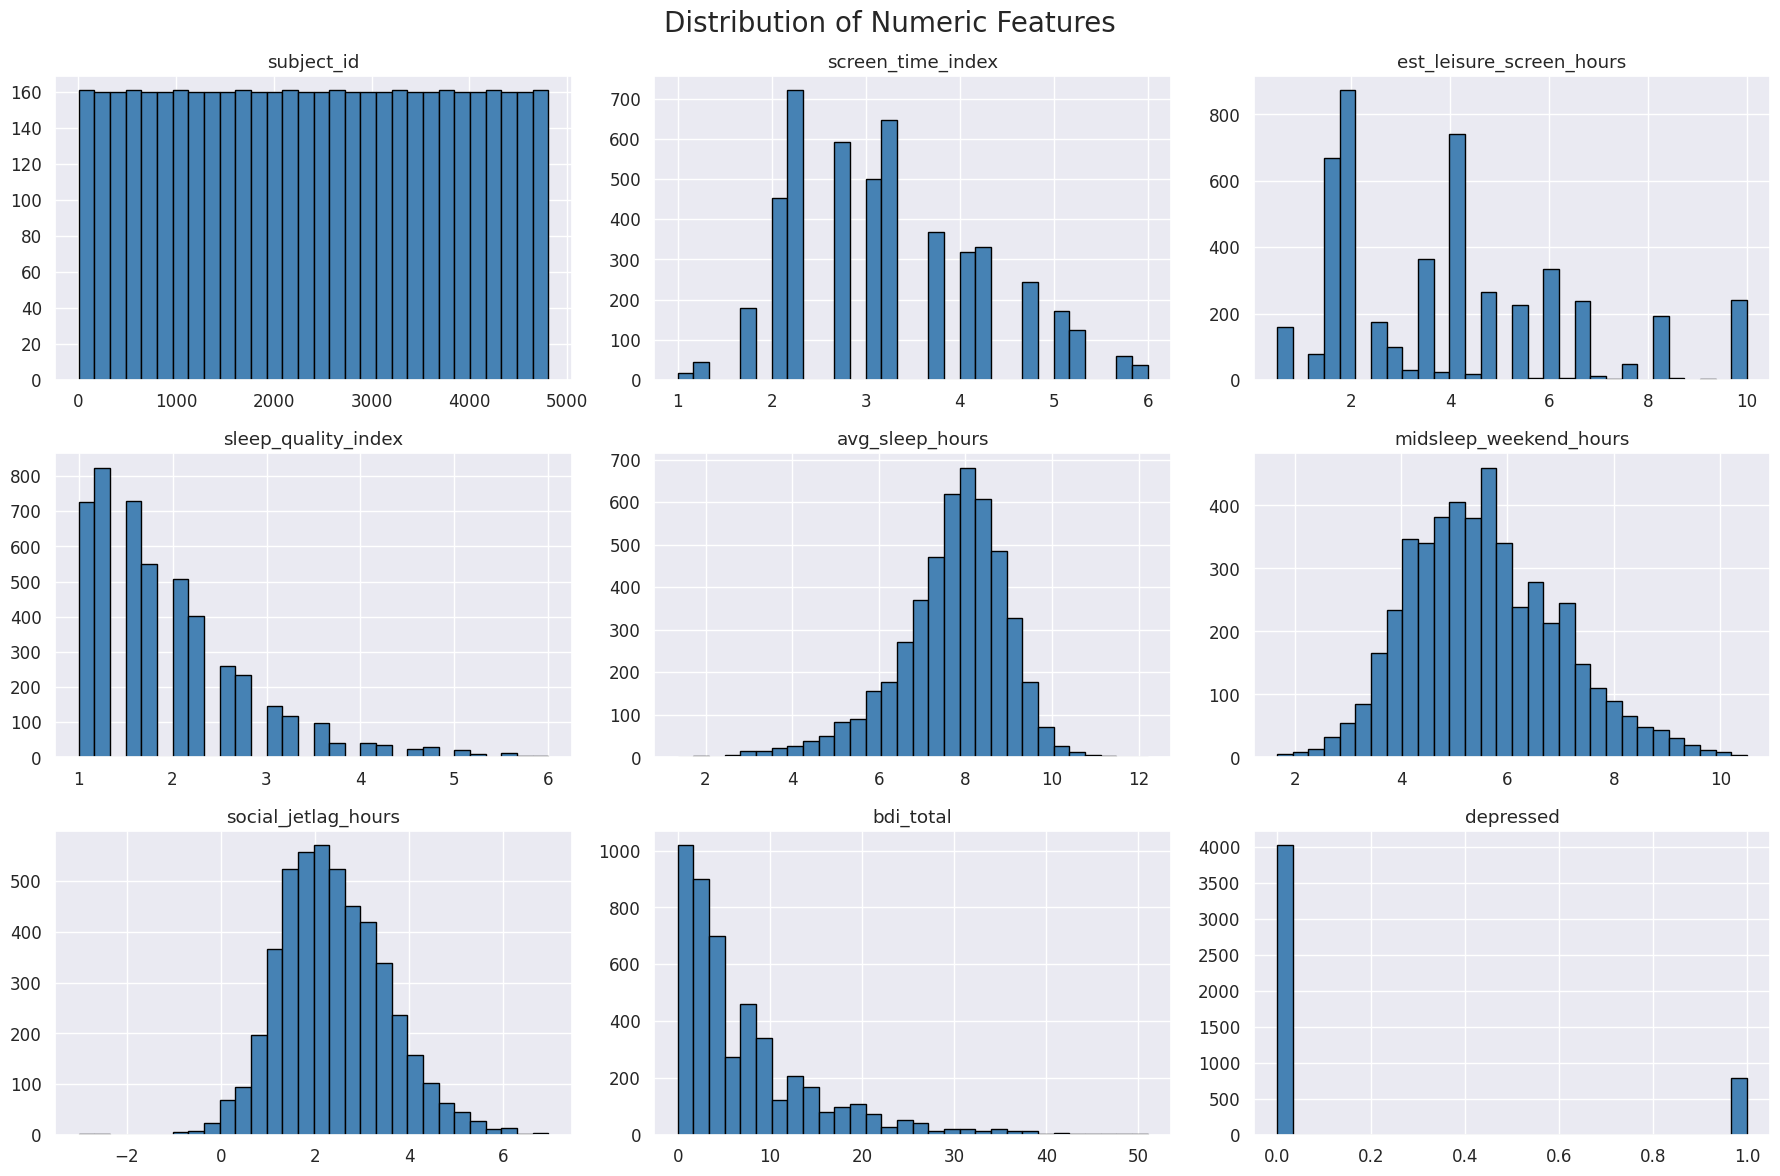

All EDA Visualizations Completed Successfully.


In [13]:
# ----------------------------------------------------------
# Style
# ----------------------------------------------------------
plt.style.use("ggplot")
sns.set(font_scale=1.1)

# ==========================================================
# 1. Missing Values Heatmap
# ==========================================================
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap", fontsize=16)
plt.show()

# ==========================================================
# 2. Data Types
# ==========================================================
print(df.dtypes)

# ==========================================================
# 3. Class Distribution
# ==========================================================
plt.figure(figsize=(6,5))
sns.countplot(x='depressed', data=df, palette='Set2')
plt.title("Depression Class Distribution", fontsize=15)
plt.xlabel("Depressed")
plt.ylabel("Count")
plt.show()

# ==========================================================
# 4. Gender Distribution
# ==========================================================
plt.figure(figsize=(6,5))
sns.countplot(x='sex', data=df, palette='Pastel1')
plt.title("Gender Distribution", fontsize=15)
plt.show()

# ==========================================================
# 5. Pie Chart of Depression
# ==========================================================
plt.figure(figsize=(6,6))
df['depressed'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','tomato'],
    explode=(0.05,0.05),
    shadow=True
)
plt.title("Depression Percentage")
plt.ylabel("")
plt.show()

# ==========================================================
# 6. Histogram - Screen Time Index
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['screen_time_index'], bins=30,
             kde=True, color='purple')
plt.title("Screen Time Index Distribution")
plt.show()

# ==========================================================
# 7. Histogram - Leisure Screen Hours
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['est_leisure_screen_hours'],
             bins=30,
             kde=True,
             color='orange')
plt.title("Estimated Leisure Screen Hours")
plt.show()

# ==========================================================
# 8. Histogram - Sleep Quality
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_quality_index'],
             bins=30,
             kde=True,
             color='green')
plt.title("Sleep Quality Index")
plt.show()

# ==========================================================
# 9. Histogram - Sleep Hours
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['avg_sleep_hours'],
             bins=30,
             kde=True,
             color='red')
plt.title("Average Sleep Hours")
plt.show()

# ==========================================================
# 10. Histogram - Social Jetlag
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['social_jetlag_hours'],
             bins=30,
             kde=True,
             color='brown')
plt.title("Social Jetlag Hours")
plt.show()

# ==========================================================
# 11. Histogram - Depression Score
# ==========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['bdi_total'],
             bins=30,
             kde=True,
             color='darkcyan')
plt.title("BDI Total Score")
plt.show()

# ==========================================================
# 12. Boxplots
# ==========================================================
columns=[
'screen_time_index',
'est_leisure_screen_hours',
'sleep_quality_index',
'avg_sleep_hours',
'midsleep_weekend_hours',
'social_jetlag_hours',
'bdi_total'
]

colors=['red','blue','green','orange',
        'purple','brown','cyan']

for col,color in zip(columns,colors):
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color=color)
    plt.title(f'Boxplot of {col}')
    plt.show()

# ==========================================================
# 13. Violin Plots
# ==========================================================
for col,color in zip(columns,colors):
    plt.figure(figsize=(8,4))
    sns.violinplot(x=df[col], color=color)
    plt.title(f'Violin Plot of {col}')
    plt.show()

# ==========================================================
# 14. Correlation Heatmap
# ==========================================================
plt.figure(figsize=(10,8))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=.5
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# 15. Pairplot
# ==========================================================
sns.pairplot(
    df[
        [
        'screen_time_index',
        'avg_sleep_hours',
        'sleep_quality_index',
        'bdi_total',
        'depressed'
        ]
    ],
    hue='depressed',
    palette='husl'
)
plt.show()

# ==========================================================
# 16. Scatter Plot
# ==========================================================
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='screen_time_index',
    y='bdi_total',
    hue='depressed',
    palette='Set1'
)

plt.title("Screen Time vs Depression Score")
plt.show()

# ==========================================================
# 17. Scatter Plot
# ==========================================================
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='avg_sleep_hours',
    y='sleep_quality_index',
    hue='depressed',
    palette='Dark2'
)

plt.title("Sleep Hours vs Sleep Quality")
plt.show()

# ==========================================================
# 18. Regression Plot
# ==========================================================
plt.figure(figsize=(8,6))

sns.regplot(
    x='screen_time_index',
    y='bdi_total',
    data=df,
    scatter_kws={'color':'purple'},
    line_kws={'color':'red'}
)

plt.title("Regression Plot")
plt.show()

# ==========================================================
# 19. Boxplot by Depression
# ==========================================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x='depressed',
    y='screen_time_index',
    data=df,
    palette='Set3'
)

plt.title("Screen Time by Depression")
plt.show()

# ==========================================================
# 20. Boxplot Sleep Quality
# ==========================================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x='depressed',
    y='sleep_quality_index',
    data=df,
    palette='Accent'
)

plt.title("Sleep Quality by Depression")
plt.show()

# ==========================================================
# 21. Boxplot BDI Score
# ==========================================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x='depressed',
    y='bdi_total',
    data=df,
    palette='coolwarm'
)

plt.title("BDI Score by Depression")
plt.show()

# ==========================================================
# 22. Countplot by Gender & Depression
# ==========================================================
plt.figure(figsize=(8,5))

sns.countplot(
    x='sex',
    hue='depressed',
    data=df,
    palette='Set1'
)

plt.title("Gender vs Depression")
plt.show()

# ==========================================================
# 23. KDE Plot
# ==========================================================
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='screen_time_index',
    hue='depressed',
    fill=True,
    palette='Set2'
)

plt.title("Density of Screen Time")
plt.show()

# ==========================================================
# 24. KDE Plot
# ==========================================================
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='avg_sleep_hours',
    hue='depressed',
    fill=True,
    palette='Paired'
)

plt.title("Density of Sleep Hours")
plt.show()

# ==========================================================
# 25. Distribution Grid
# ==========================================================
numeric=df.select_dtypes(include=np.number)

numeric.hist(
    figsize=(18,12),
    bins=30,
    color='steelblue',
    edgecolor='black'
)

plt.suptitle("Distribution of Numeric Features",
             fontsize=20)

plt.tight_layout()

plt.show()

# ==========================================================
# End of Visualization
# ==========================================================

print("All EDA Visualizations Completed Successfully.")

## Feature engineering

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc


Logistic Regression
Accuracy : 99.90%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      0.99      1.00       157

    accuracy                           1.00       962
   macro avg       1.00      1.00      1.00       962
weighted avg       1.00      1.00      1.00       962

Decision Tree
Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00       157

    accuracy                           1.00       962
   macro avg       1.00      1.00      1.00       962
weighted avg       1.00      1.00      1.00       962

Random Forest
Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00       157

    accuracy                           1.00       962
   macro avg       1.00 

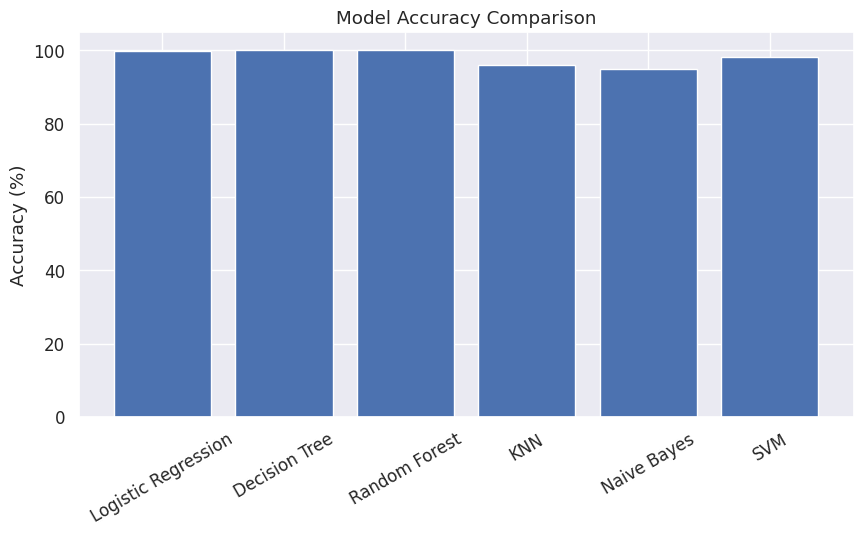

In [15]:
# ===========================
# Fill Missing Values
# ===========================
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ===========================
# Label Encoding
# ===========================
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# ===========================
# Features and Target
# ===========================
X = df.drop("depressed", axis=1)
y = df["depressed"]

# ===========================
# Train Test Split
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===========================
# Feature Scaling
# ===========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===========================
# Models
# ===========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

accuracy = []

# ===========================
# Train Models
# ===========================
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy.append(acc)

    print("="*50)
    print(name)
    print("Accuracy : {:.2f}%".format(acc*100))
    print(classification_report(y_test, y_pred))

# ===========================
# Accuracy Comparison
# ===========================
result = pd.DataFrame({
    "Model":models.keys(),
    "Accuracy (%)":[i*100 for i in accuracy]
})

print(result)

# ===========================
# Accuracy Bar Plot
# ===========================
plt.figure(figsize=(10,5))

plt.bar(result["Model"],
        result["Accuracy (%)"])

plt.xticks(rotation=30)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy Comparison")

plt.show()


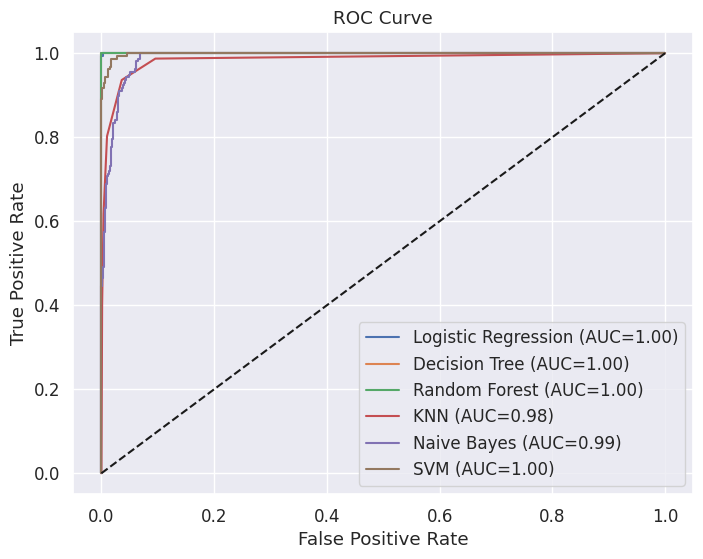

In [16]:
# ===========================
# ROC Curve
# ===========================
plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model,"predict_proba"):

        y_prob = model.predict_proba(X_test)[:,1]

    else:

        y_prob = model.decision_function(X_test)

    fpr,tpr,_ = roc_curve(y_test,y_prob)

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,
             label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Thank you...pls upvote!!!!!!!!!